Bayesian Network Analysis

**Name:** Nakedi Lebeya  


**Dataset Source:**  
[Data modelling of subsistence retail consumer purchase behavior in South Africa](https://www.sciencedirect.com/science/article/pii/S2352340922003043)



##Notebook Structure

This notebook follows the **CRISP-DM process** for structured data science analysis:

1. **Business Understanding**  
   - Define the project objectives and business questions.  
   - Explain why Bayesian Networks are useful for understanding purchase intention.

2. **Data Understanding**  
   - Explore the dataset to identify key variables.  
   - Visualize correlations using heatmaps to understand relationships among variables.  
   - Identify potential data quality issues and patterns.

3. **Data Preparation**  
   - Clean and preprocess the data (remove invalid values, handle missing data).  
   - Perform feature engineering to create constructs (e.g. Convenience, Price Sensitivity).  
  

4. **Modeling**  
   - Build the Expert Bayesian Network (DAG 2.1) based on domain knowledge.  
   - Build the Learned Bayesian Network(DAG 2.2) using Hill-Climb Search and AIC scoring.  
   - Visualization of both networks.

5. **Evaluation**  
   - Compare the Expert and Learned DAGs using a confusion matrix and visual DAG.  
   - Show common and unique edges between the two models.  

6. **Parameter Learning**  
   - Learn Conditional Probability Distributions (CPDs) using Maximum Likelihood Estimation (MLE).  
   - Examine CPDs for key variables to understand probabilistic relationships.

7. **Insights & Conclusion**  
   - Infer patterns and trends from the Bayesian Network.  
   - Discuss actionable insights for subsistence retailers or marketing strategies.  

8. **Model Deployment**
    - Practical use of the model

9. **Reference**



##1. Business Understanding

The first phase of the CRISP-DM process focuses on understanding the business objectives and defining a clear plan to solve the problem. In this project, the goal is to build and compare Bayesian Network models to determine the relationships between factors that influence purchase intention among small-scale consumers, as indicated in dataset we were provided with.

From a business perspective, understanding how **demographic, behavioral, and perception-based variables** interact to affect purchase decisions is crucial. This understadning can help businesses design more effective marketing,commmunication,and pricing strategies that focues on improving consumer engagement and promoting maintainable purchasing behavior.

To accomplish this, the following objectives were defined:

- Identify and model the key factors that influence **purchase intention**.  
- Use **Bayesian Networks** to visualize dependencies among variables.  
- Compare an expert built network which is based on domain knowledge with a data-driven network (learned using Hill-Climb Search and Akaike Information Criterion).  
- Evaluate both DAGs to see how well the learned model reflects real-world relationships.  
- Learn the conditional probability parameters to understand the likelihood of outcomes under different conditions.


This phase sets up a foundation for the rest of the project by aligning technical modeling tasks with the overall business goal, getting **data-driven insights** into the factors that shape consumer purchase behavior.


#Install Packages and Libraries

In [ ]:
!pip install bnlearn

In [ ]:
import bnlearn as bn
import pandas as pd

In [ ]:
print("bnlearn version is:", bn.__version__)
print("pandas version is:", pd.__version__)

bnlearn version is: 0.12.0
pandas version is: 2.2.2


#Import your data

In [ ]:
#Link your data via Google sheets use the following code:
import gdown #for importing data from Google Drive
import os #zip unzip from Google Drive

'''
#https://docs.google.com/spreadsheets/d/copythispartofthelink/edit?usp=sharing
#Please paste your link below this link and copy the right part of the link in below

#Important
#Make sure that your Google Sheet is Public, anyone with link can access, otherwise it will not work.

spreadsheet_file_id = 'copythispartofthelink'
output_filename = 'Youroutputfile'

# Download the single spreadsheet file
gdown.download(id=spreadsheet_file_id, output=output_filename, quiet=False)

print(f"Spreadsheet downloaded as {output_filename}")'''


'\n#https://docs.google.com/spreadsheets/d/copythispartofthelink/edit?usp=sharing\n#Please paste your link below this link and copy the right part of the link in below\n\n#Important\n#Make sure that your Google Sheet is Public, anyone with link can access, otherwise it will not work.\n\nspreadsheet_file_id = \'copythispartofthelink\'\noutput_filename = \'Youroutputfile\'\n\n# Download the single spreadsheet file\ngdown.download(id=spreadsheet_file_id, output=output_filename, quiet=False)\n\nprint(f"Spreadsheet downloaded as {output_filename}")'

In [ ]:
# Replace 'your_data.csv' with the actual path to your dataset
retail = pd.read_excel(r"/content/sample_data/Subsistence Retail Consumer Data.xlsx")
retail.head(10)


,Gender,Age,Marital Status,Employment Status,Level of Education,Regular Customer,Shopping frequency,E1,E2,E3,...,CT5,CT6,CT7,PV1,PV2,PV3,PI1,PI2,PI3,PI4
0,3,4,1,1,4,2,3,3,2,4,...,3,2,4,2,4,4,3,4,4,4
1,3,5,3,1,4,1,1,3,3,3,...,2,4,3,2,3,2,4,4,4,4
2,2,4,2,2,2,2,2,3,4,2,...,2,4,1,2,3,1,3,3,4,3
3,1,3,1,1,3,2,1,3,2,4,...,2,3,4,1,2,3,3,4,3,4
4,3,2,1,2,2,2,3,2,4,3,...,2,4,2,2,4,2,2,3,2,3
5,1,1,2,1,4,2,2,3,4,2,...,2,4,3,2,3,3,4,4,4,4
6,1,5,2,2,1,1,5,4,4,4,...,4,3,3,1,2,3,2,1,1,2
7,3,3,3,2,1,2,1,2,4,3,...,3,4,3,3,2,4,2,2,2,2
8,2,2,1,1,3,2,1,4,4,4,...,2,3,4,5,3,4,4,5,4,4
9,2,2,1,1,3,1,2,3,3,3,...,3,4,5,4,4,4,5,5,5,5


#EDA / Feature engineer your data

##2. Data Understanding

In this step, We explored the dataset to understand its structure and format format  
The goal is to familiarize with the data, identify missing values, and get insights into the types of variables we have.

The following actions were taken:
- Column names were cleaned to make them Python-friendly.  
- The dataset’s structure and variable types were reviewed using **info()**.  
- Descriptive statistics were checked to understand distributions of numerical features.  
- Missing values were checked to check whether the dataset is complete.  

This step helps identify early data quality issues before further processing and modeling.


In [ ]:
# Make all column
retail.columns = [col.strip().replace(" ", "_") for col in retail.columns]

print(retail.columns)

Index(['Gender', 'Age', 'Marital_Status', 'Employment_Status',
       'Level_of_Education', 'Regular_Customer', 'Shopping_frequency', 'E1',
       'E2', 'E3', 'E4', 'C1', 'C2', 'C3', 'PS1', 'PS2', 'PS3', 'PE1', 'PE2',
       'PE3', 'PE4', 'PE5', 'PE6', 'PPQ1', 'PPQ2', 'PPQ3', 'PPQ4', 'CT1',
       'CT2', 'CT3', 'CT4', 'CT5', 'CT6', 'CT7', 'PV1', 'PV2', 'PV3', 'PI1',
       'PI2', 'PI3', 'PI4'],
      dtype='object')


In [ ]:
#basic information about the DataFrame
print("\nDataFrame Info:")
retail.info()

#descriptive statistics for numeric columns
print("\nDescriptive Statistics:")
print(retail.describe())

#Checks for missing values
print("\nMissing Values per Column:")
retail.isnull().sum()



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Gender              281 non-null    int64
 1   Age                 281 non-null    int64
 2   Marital_Status      281 non-null    int64
 3   Employment_Status   281 non-null    int64
 4   Level_of_Education  281 non-null    int64
 5   Regular_Customer    281 non-null    int64
 6   Shopping_frequency  281 non-null    int64
 7   E1                  281 non-null    int64
 8   E2                  281 non-null    int64
 9   E3                  281 non-null    int64
 10  E4                  281 non-null    int64
 11  C1                  281 non-null    int64
 12  C2                  281 non-null    int64
 13  C3                  281 non-null    int64
 14  PS1                 281 non-null    int64
 15  PS2                 281 non-null    int64
 16  PS3                 281 non

,0
Gender,0
Age,0
Marital_Status,0
Employment_Status,0
Level_of_Education,0
Regular_Customer,0
Shopping_frequency,0
E1,0
E2,0
E3,0


##3. Data Preparation

The data preparation phase focuses on cleaning and transforming the dataset to make it fit for modeling.  
It includes handling missing or invalid values, combining related survey items into constructs, and scaling values for consistent analysis.

Key actions takenn in this step:
-  Data errors such as invalid Likert-scale responses and incorrect demographic values are removed.  
- A clean dataset named **(clean_retail)** is created containing only valid observations.  
- Performed **feature engineering** by averaging related items into broader constructs ( **Empathy**, **Convenience**, **Price Sensitivity**, and **Customer Trust**).  
-  Only relevant demographic and construct variables for modeling are kept.  


This cleaned and preprocessed dataset is now ready to be used for Bayesian Network structure learning.


# Outliers

In [ ]:
import pandas as pd
import numpy as np


# Clean retail data

def get_data_errors(df):
    """
    Get dataframe containing ONLY data errors (not statistical outliers)
    Invalid Likert scale values (outside 1-5)
    Invalid demographic categories
    Missing values
    """

    # Gets Likert scale errors (values outside 1-5)
    likert_columns = [col for col in df.columns if any(
        col.startswith(prefix) for prefix in ['E', 'C', 'PS', 'PE', 'PPQ', 'CT', 'PV', 'PI']
    )]

    likert_error_mask = pd.Series([False] * len(df), index=df.index)
    for col in likert_columns:
        if col in df.columns:
            likert_error_mask |= (df[col] < 1) | (df[col] > 5)

    # Gets demographic errors
    demographic_checks = {
        'Gender': [1, 2, 3],
        'Age': [1, 2, 3, 4, 5],
        'Marital_Status': [1, 2, 3],
        'Employment_Status': [1, 2],
        'Level_of_Education': [1, 2, 3, 4, 5],
        'Regular_Customer': [1, 2, 3],
        'Shopping_Frequency': [1, 2, 3, 4, 5]
    }

    demographic_error_mask = pd.Series([False] * len(df), index=df.index)
    for col, valid_values in demographic_checks.items():
        if col in df.columns:
            demographic_error_mask |= ~df[col].isin(valid_values)

    # Get missing values
    missing_error_mask = df.isnull().any(axis=1)

    # Combine all error masks
    all_errors_mask = likert_error_mask | demographic_error_mask | missing_error_mask

    # Create error dataframe
    error_df = df[all_errors_mask].copy()

    # Add columns to identify error types
    error_df['has_likert_error'] = error_df.index.isin(df[likert_error_mask].index)
    error_df['has_demographic_error'] = error_df.index.isin(df[demographic_error_mask].index)
    error_df['has_missing_values'] = error_df.index.isin(df[missing_error_mask].index)

    # Add details about which columns have errors
    if len(error_df) > 0:
        # Identify problematic Likert columns
        error_df['problematic_likert_cols'] = error_df.apply(
            lambda row: ', '.join([col for col in likert_columns
                                  if col in df.columns and (row[col] < 1 or row[col] > 5)])
                        if pd.notna(row.name) else '',
            axis=1
        )

        # Identify problematic demographic columns
        error_df['problematic_demographic_cols'] = error_df.apply(
            lambda row: ', '.join([col for col, valid_values in demographic_checks.items()
                                  if col in df.columns and row[col] not in valid_values])
                        if pd.notna(row.name) else '',
            axis=1
        )

        # Identify columns with missing values
        error_df['missing_value_cols'] = error_df.apply(
            lambda row: ', '.join([col for col in df.columns if pd.isnull(row[col])]),
            axis=1
        )

    return error_df, all_errors_mask


def clean_retail_data(df, display_errors=True):
    # Get data errors
    error_df, error_mask = get_data_errors(df)

    # Create clean dataframe
    clean_df = df[~error_mask].copy()
    print(f"\nCleaned dataset: {len(clean_df)} rows ({len(clean_df)/len(df)*100:.2f}%)")


    # Display error details if requested
    if display_errors and len(error_df) > 0:
        print("ERROR DETAILS")
        print("=" * 70)

        # Show summary of errors by type
        error_summary = error_df[['has_likert_error', 'has_demographic_error',
                                  'has_missing_values']].sum()
        print("\nError counts by type:")
        print(error_summary)
        print("Sample of error rows (first 10):")

        display_cols = ['has_likert_error', 'has_demographic_error', 'has_missing_values',
                       'problematic_likert_cols', 'problematic_demographic_cols',
                       'missing_value_cols']
        print(error_df[display_cols].head(10))

    return clean_df, error_df

# Clean the retail dataframe
clean_retail, error_records = clean_retail_data(retail, display_errors=True)

# Display of all error records (if they exist))
print("All error records ")
error_records

print("Summary")
print(f"Original 'retail' dataframe: {len(retail)} rows")
print(f"'error_records' dataframe: {len(error_records)} rows (removed)")
print(f"'clean_retail' dataframe: {len(clean_retail)} rows (to use for analysis)")




Cleaned dataset: 281 rows (100.00%)
All error records 
Summary
Original 'retail' dataframe: 281 rows
'error_records' dataframe: 0 rows (removed)
'clean_retail' dataframe: 281 rows (to use for analysis)


# Feature Engineering

In this step I combined related questionnaire items into **constructs**  

- For example, the questions E1 to E4 all measure **Empathy**, so they are averaged to create Empathy score.  

**Justification:**  
- This is a type of feature engineering that simplifies the dataset by reducing multiple related columns into one. It helps capture the overall concept measured by multiple items, making analysis and modeling easier.  
- It also reduces noise and improves the interpretability of correlations of Bayesian networks


In [ ]:

#Construct groupings
constructs = {
    # Section B: Measurment instruments
    "Empathy": ["E1", "E2", "E3", "E4"],
    "Convenience": ["C1", "C2", "C3"],
    "Price_Sensitivity": ["PS1", "PS2", "PS3"],
    "Physical_Environment": ["PE1", "PE2", "PE3", "PE4", "PE5", "PE6"],
    "Perceived_Product_Quality": ["PPQ1", "PPQ2", "PPQ3", "PPQ4"],
    "Customer_Trust": ["CT1", "CT2", "CT3", "CT4", "CT5", "CT6", "CT7"],
    "Perceived_Value": ["PV1", "PV2", "PV3"],
    "Purchase_Intention": ["PI1", "PI2", "PI3", "PI4"]
}


# Compute the mean of each construct
for construct, items in constructs.items():
    available_items = [col for col in items if col in retail.columns]
    if available_items:
        retail[construct] = retail[available_items].mean(axis=1).round(2)
    else:
        print(f"Warning: None of the items for '{construct}' were found in the DataFrame.")

retail.head(10)

,Gender,Age,Marital_Status,Employment_Status,Level_of_Education,Regular_Customer,Shopping_frequency,E1,E2,E3,...,PI3,PI4,Empathy,Convenience,Price_Sensitivity,Physical_Environment,Perceived_Product_Quality,Customer_Trust,Perceived_Value,Purchase_Intention
0,3,4,1,1,4,2,3,3,2,4,...,4,4,3.25,2.67,2.33,3.00,3.50,3.14,3.33,3.75
1,3,5,3,1,4,1,1,3,3,3,...,4,4,3.00,4.00,3.00,3.17,2.50,2.86,2.33,4.00
2,2,4,2,2,2,2,2,3,4,2,...,4,3,3.00,3.33,3.00,2.83,3.25,2.71,2.00,3.25
3,1,3,1,1,3,2,1,3,2,4,...,3,4,3.00,2.67,4.00,3.17,3.00,2.86,2.00,3.50
4,3,2,1,2,2,2,3,2,4,3,...,2,3,2.75,3.33,2.33,2.83,3.00,2.86,2.67,2.50
5,1,1,2,1,4,2,2,3,4,2,...,4,4,3.00,2.00,3.00,2.50,3.25,3.14,2.67,4.00
6,1,5,2,2,1,1,5,4,4,4,...,1,2,3.75,2.33,3.33,3.33,2.00,3.14,2.00,1.50
7,3,3,3,2,1,2,1,2,4,3,...,2,2,3.00,3.00,4.00,2.67,3.00,3.29,3.00,2.00
8,2,2,1,1,3,2,1,4,4,4,...,4,4,4.00,2.33,3.00,3.00,2.50,3.14,4.00,4.25
9,2,2,1,1,3,1,2,3,3,3,...,5,5,3.00,3.33,3.00,2.50,3.25,3.86,4.00,5.00


In [ ]:
# Keep only demographics + constructs individual survey items are removed
columns_to_keep = [
    # Demographics
    'Gender', 'Age', 'Marital_Status', 'Employment_Status',
    'Level_of_Education', 'Regular_Customer', 'Shopping_frequency',

    # Constructs (aggregated)
    'Empathy', 'Convenience', 'Price_Sensitivity',
    'Physical_Environment', 'Perceived_Product_Quality',
    'Customer_Trust', 'Perceived_Value', 'Purchase_Intention'
]

# Create clean dataset
clean_retail_final = retail[columns_to_keep].copy()
clean_retail_final
print(f"Original columns: {len(clean_retail.columns)}")
print(f"Final columns: {len(clean_retail_final.columns)}")
retail = clean_retail_final


Original columns: 41
Final columns: 15


In [ ]:
retail

,Gender,Age,Marital_Status,Employment_Status,Level_of_Education,Regular_Customer,Shopping_frequency,Empathy,Convenience,Price_Sensitivity,Physical_Environment,Perceived_Product_Quality,Customer_Trust,Perceived_Value,Purchase_Intention
0,3,4,1,1,4,2,3,3.25,2.67,2.33,3.00,3.50,3.14,3.33,3.75
1,3,5,3,1,4,1,1,3.00,4.00,3.00,3.17,2.50,2.86,2.33,4.00
2,2,4,2,2,2,2,2,3.00,3.33,3.00,2.83,3.25,2.71,2.00,3.25
3,1,3,1,1,3,2,1,3.00,2.67,4.00,3.17,3.00,2.86,2.00,3.50
4,3,2,1,2,2,2,3,2.75,3.33,2.33,2.83,3.00,2.86,2.67,2.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,1,3,1,2,3,1,2,2.50,4.00,3.00,3.50,3.00,2.71,3.33,4.25
277,2,3,3,1,2,1,1,3.25,3.33,3.33,3.50,3.00,2.86,2.67,3.75
278,2,4,3,1,3,1,2,4.00,3.33,4.00,3.50,4.00,4.29,4.00,4.75
279,2,5,2,2,3,1,1,3.00,4.00,2.33,2.83,3.75,3.00,3.33,4.00


## Heatmap Visualisations

- The first heatmap shows how each variable is correlated with Purchase_Intention.  
- The second heatmap shows correlations between all numerical variables in the dataset.  
- Strong positive or negative correlations help identify which factors may affect customer purchase behavior.


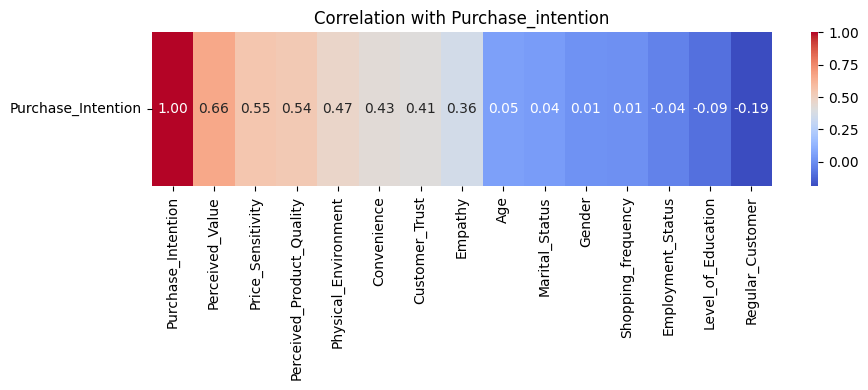

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlations with 'Purchase_intention'
correlations = retail.corr(numeric_only=True)['Purchase_Intention'].sort_values(ascending=False)

# Convert to DataFrame for heatmap
corr_df = pd.DataFrame(correlations).T

plt.figure(figsize=(10, 2))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with Purchase_intention")
plt.yticks(rotation=0)
plt.show()


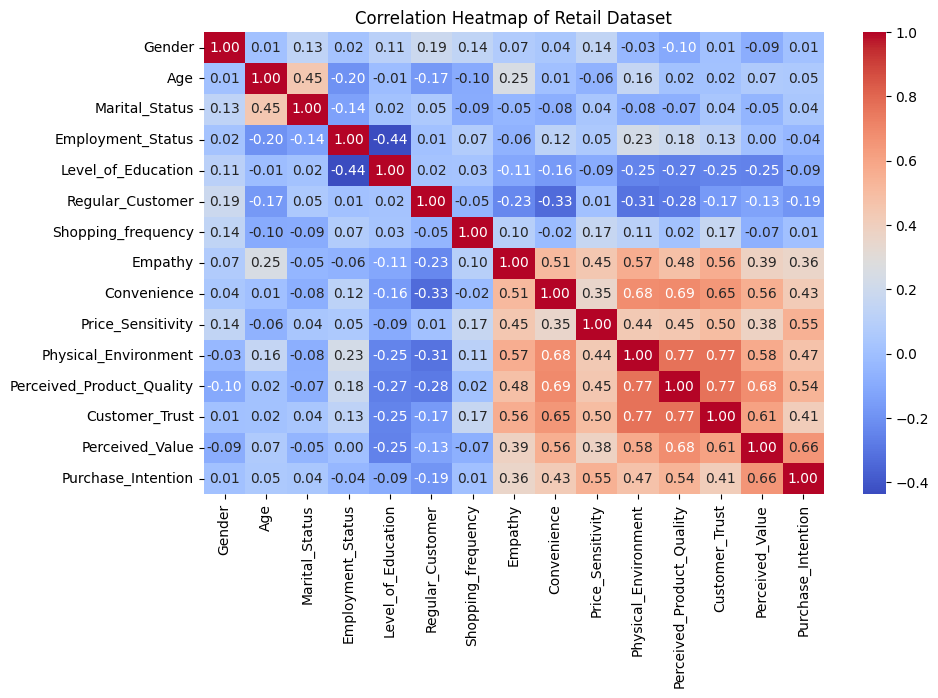

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#Basic heatmap (includes all the factors)
plt.figure(figsize=(10, 6))
sns.heatmap(retail.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Retail Dataset")
plt.show()


##Step 4: Modeling

In this phase, two Bayesian Network models are built:

1. The **Expert Model (DAG  in question2.1)** — this model is constructed using intuition knowledge about how different variables influence each other.
2. **Learned Model (DAG in question 2.2)** — this one automatically learnes from the dataset using the **Hill-Climb Search** algorithm with the **AIC score**.

Both models are visualized to compare their network structures and edges relationships between variables.


#Build your Bayesian Networks (Structure Learning)

### Expert DAG

**Parent Nodes:**  
- Age  
- Level of Education  
- Physical Environment  
- Convenience  
- Perceived Product Quality  
- Customer Trust  
- Regular Customer  

**Child Nodes:**  
- Marital Status  
- Employment Status  
- Price Sensitivity  
- Customer Trust  
- Perceived Product Quality  
- Purchase Intention


In [ ]:
import bnlearn as bn

#expert DAG edges
edges = [
    ('Perceived_Product_Quality', 'Purchase_Intention'),
    ('Perceived_Value', 'Purchase_Intention'),
    ('Physical_Environment', 'Convenience'),
    ('Customer_Trust', 'Perceived_Value'),
    ('Perceived_Product_Quality', 'Customer_Trust'),
    ('Level_of_Education', 'Customer_Trust'),
    ('Perceived_Product_Quality', 'Price_Sensitivity'),
    ('Customer_Trust', 'Price_Sensitivity'),
    ('Age', 'Price_Sensitivity'),
    ('Employment_Status', 'Price_Sensitivity'),
    ('Regular_Customer', 'Customer_Trust'),
    ('Level_of_Education', 'Employment_Status'),
    ('Age', 'Marital_Status'),
    ('Convenience', 'Perceived_Product_Quality')
]

#Create DAG
expert_model = bn.make_DAG(edges)

#Node color mapping
node_colors = {
    'Age': 'pink',
    'Marital Status': 'pink',
    'Employment Status': 'pink',
    'Education level': 'pink',
    'Regular Customer': 'pink',
    'Convenience': 'blue',
    'Price Sensitivity': 'red',
    'Physical Environment': 'teal',
    'Perceived Product Quality': 'orange',
    'Customer Trust': 'purple',
    'Perceived Value': 'turquoise',
    'Purchase Intention': 'whitesmoke'
}

#Plots the DAG
'''bn.plot(expert_model,params_static={
              'node_color': '#B3A7FF',
              'layout': 'spring_layout',
              'figsize': (14, 10),
              'font_size': 14,
              'font_family': 'sans-serif',
              'edge_alpha': 0.7,
              'node_size': 3500,
              'arrowsize': 25
            }
)

'''

[bnlearn]> Auto generate placeholders for the CPTs.
[bnlearn] >CPT for Purchase_Intention:
+---------------------------+-----+------------------------------+
| Perceived_Product_Quality | ... | Perceived_Product_Quality(1) |
+---------------------------+-----+------------------------------+
| Perceived_Value           | ... | Perceived_Value(1)           |
+---------------------------+-----+------------------------------+
| Purchase_Intention(0)     | ... | 0.5                          |
+---------------------------+-----+------------------------------+
| Purchase_Intention(1)     | ... | 0.5                          |
+---------------------------+-----+------------------------------+
[bnlearn] >CPT for Convenience:
+----------------------+-------------------------+-------------------------+
| Physical_Environment | Physical_Environment(0) | Physical_Environment(1) |
+----------------------+-------------------------+-------------------------+
| Convenience(0)       | 0.5               

"bn.plot(expert_model,params_static={\n              'node_color': '#B3A7FF',\n              'layout': 'spring_layout',\n              'figsize': (14, 10),\n              'font_size': 14,\n              'font_family': 'sans-serif',\n              'edge_alpha': 0.7,\n              'node_size': 3500,\n              'arrowsize': 25\n            }\n)\n\n"

#Bayesian Network DAG Visualizations

We visualized both the Expert and Learned Bayesian Networks using Network* and Matplotlib. NetworkX makes it easier to draw clear and visually appealing DAGs, they showe nodes and directed edges  in an organized layout.  

- The Expert DAG represents relationships based on Intuition and theory
- The Learned DAG represents relationships learned directly from the dataset.  



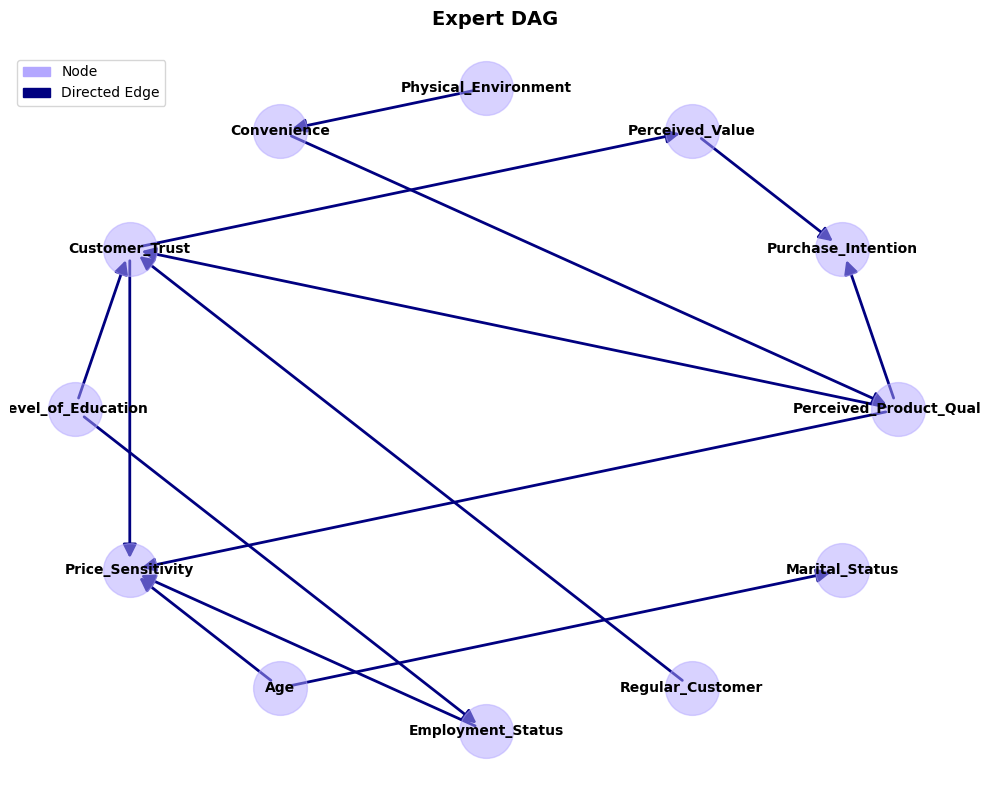

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Extract expert DAG
G_expert = expert_model['model']

# Use a layout
pos = nx.kamada_kawai_layout(G_expert)

plt.figure(figsize=(10, 8))

# Draw nodes
nx.draw_networkx_nodes(G_expert, pos, node_color='#B3A7FF', node_size=1500, alpha=0.5)
nx.draw_networkx_labels(G_expert, pos, font_color='black', font_size=10, font_weight='bold')

# Draw edges one by one to avoid StopIteration errors
for edge in G_expert.edges():
    nx.draw_networkx_edges(
        G_expert,
        pos,
        edgelist=[edge],
        arrows=True,
        arrowstyle='-|>',
        arrowsize=20,
        width=2,
        edge_color='navy'
    )

# Title and axis
plt.title("Expert DAG", fontsize=14, fontweight='bold', pad=20)
plt.axis('off')

# Legend
node_patch = mpatches.Patch(color='#B3A7FF', label='Node')
edge_patch = mpatches.Patch(color='navy', label='Directed Edge')
plt.legend(handles=[node_patch, edge_patch], loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:

bn_model = bn.structure_learning.fit(
    retail,
    methodtype='hc',
    scoretype='aic',
    max_iter=500,
    tabu_length=50
)

#Shows the edges learned
print("Learned DAG edges:")
#print(model['model'].edges())
'''
#Visualize the DAG
figsize=(6,3)
bn.plot(
    bn_model,
    interactive=False,
    node_color='#2ecc71',

)

'''

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [aic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
Learned DAG edges:


"\n#Visualize the DAG\nfigsize=(6,3)\nbn.plot(\n    bn_model,\n    interactive=False,\n    node_color='#2ecc71',\n\n)\n\n"

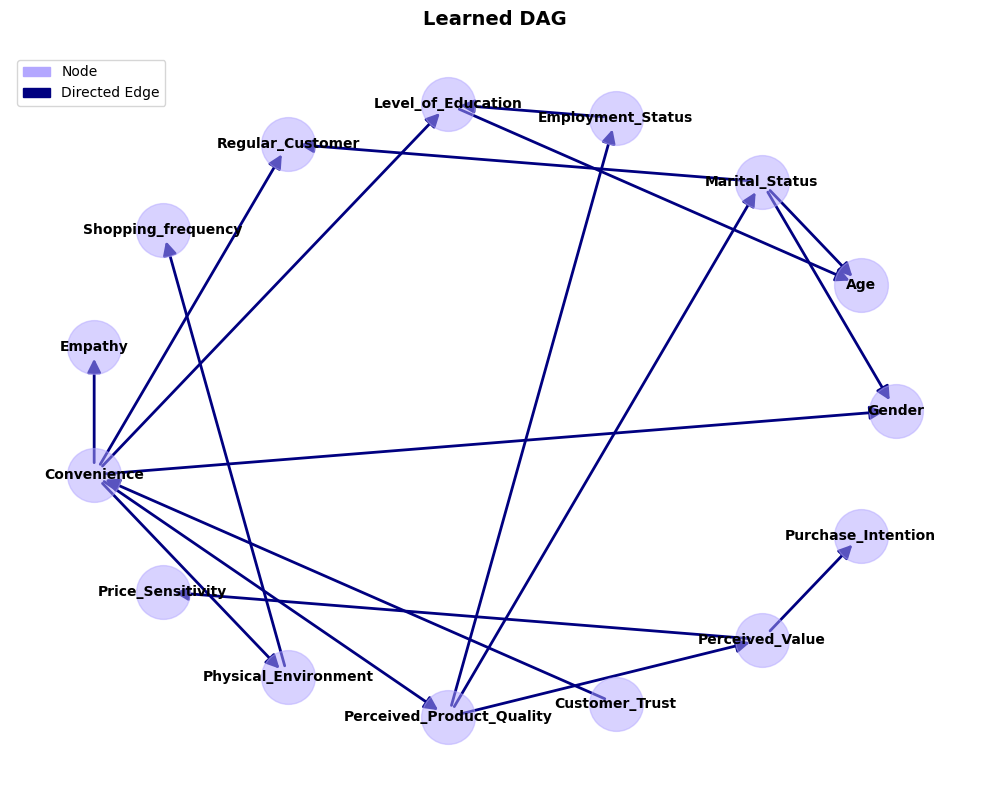

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Extract expert DAG
G_learned = bn_model['model']

# Use a layout
pos = nx.kamada_kawai_layout(G_learned)

plt.figure(figsize=(10, 8))

# Draw nodes
nx.draw_networkx_nodes(G_learned, pos, node_color='#B3A7FF', node_size=1500, alpha=0.5)
nx.draw_networkx_labels(G_learned, pos, font_color='black', font_size=10, font_weight='bold')

# we draw edges one by one
for edge in G_learned.edges():
    nx.draw_networkx_edges(
        G_learned,
        pos,
        edgelist=[edge],
        arrows=True,
        arrowstyle='-|>',
        arrowsize=20,
        width=2,
        edge_color='navy'
    )

# Title and axis
plt.title("Learned DAG", fontsize=14, fontweight='bold', pad=20)
plt.axis('off')

# Legend
node_patch = mpatches.Patch(color='#B3A7FF', label='Node')
edge_patch = mpatches.Patch(color='navy', label='Directed Edge')
plt.legend(handles=[node_patch, edge_patch], loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
model1 = bn.independence_test(bn_model, retail, alpha=0.05, prune=False)
model1

[bnlearn] >Compute edge strength with [chi_square]


{'model': <pgmpy.base.DAG.DAG at 0x7fa48bad68d0>,
 'model_edges': [('Marital_Status', 'Age'),
  ('Marital_Status', 'Gender'),
  ('Marital_Status', 'Regular_Customer'),
  ('Employment_Status', 'Level_of_Education'),
  ('Level_of_Education', 'Age'),
  ('Convenience', 'Physical_Environment'),
  ('Convenience', 'Perceived_Product_Quality'),
  ('Convenience', 'Empathy'),
  ('Convenience', 'Level_of_Education'),
  ('Convenience', 'Regular_Customer'),
  ('Convenience', 'Gender'),
  ('Physical_Environment', 'Shopping_frequency'),
  ('Perceived_Product_Quality', 'Perceived_Value'),
  ('Perceived_Product_Quality', 'Marital_Status'),
  ('Perceived_Product_Quality', 'Employment_Status'),
  ('Customer_Trust', 'Convenience'),
  ('Perceived_Value', 'Price_Sensitivity'),
  ('Perceived_Value', 'Purchase_Intention')],
 'adjmat': target                     Gender    Age  Marital_Status  Employment_Status  \
 source                                                                        
 Gender           

#Step 5: Evaluation

In this step, we compare the **Expert DAG** and the **Learned DAG** to see how they align.

We use:
- A **confusion matrix** to measure edge overlaps and differences.
- **Visual comparison plots (DAGs)** showing common and unique edges between the two models.

This helps assess how well the learned model reflects expert understanding and whether the algorithm discovered any new relevnt  relationships.


#Compare your 2 Bayesian Networks

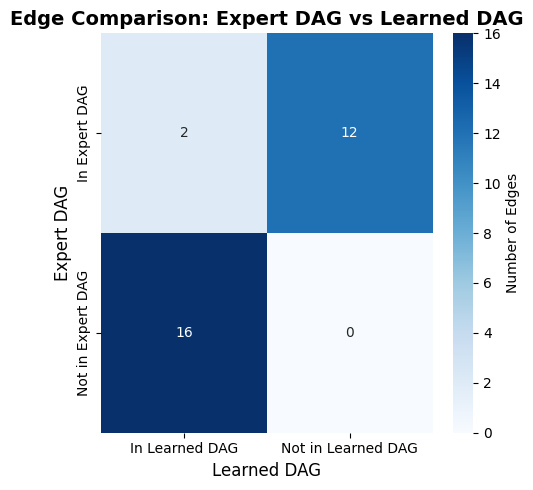

 summary of Edge comparison 
Edges in both models: 2
Edges only in Expert DAG: 12
Edges only in Learned DAG: 16
Total Expert edges: 14
Total Learned edges: 18
Agreement rate: 6.7%

Edges in both models
Convenience → Perceived_Product_Quality
Perceived_Value → Purchase_Intention

Edges only in expert DAG (Missed by algorithm)
- Age → Marital_Status
- Age → Price_Sensitivity
- Customer_Trust → Perceived_Value
- Customer_Trust → Price_Sensitivity
- Employment_Status → Price_Sensitivity
- Level_of_Education → Customer_Trust
- Level_of_Education → Employment_Status
- Perceived_Product_Quality → Customer_Trust
- Perceived_Product_Quality → Price_Sensitivity
- Perceived_Product_Quality → Purchase_Intention
- Physical_Environment → Convenience
- Regular_Customer → Customer_Trust
Edges only in leanerd DAG (Found by algorithm)
+ Convenience → Empathy
+ Convenience → Gender
+ Convenience → Level_of_Education
+ Convenience → Physical_Environment
+ Convenience → Regular_Customer
+ Customer_Trust → 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#expert DAG edges from 2.1
expert_edges = list(G_expert.edges())

#learned DAG edges from 2.2
learned_edges = list(bn_model['model'].edges())

#confusion matrix
expert_set = set(expert_edges)
learned_set = set(learned_edges)

# Calculate categories
both = expert_set & learned_set
only_expert = expert_set - learned_set
only_learned = learned_set - expert_set
neither = 0

#Create confusion matrix
confusion_data = np.array([
    [len(both), len(only_expert)],
    [len(only_learned), 0]
])

#confusion matrix visualisation
plt.figure(figsize=(5,5))
sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Blues',
            xticklabels=['In Learned DAG', 'Not in Learned DAG'],
            yticklabels=['In Expert DAG', 'Not in Expert DAG'],
            cbar_kws={'label': 'Number of Edges'})
plt.title('Edge Comparison: Expert DAG vs Learned DAG', fontsize=14, fontweight='bold')
plt.xlabel('Learned DAG', fontsize=12)
plt.ylabel('Expert DAG', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()



print(" summary of Edge comparison ")

print(f"Edges in both models: {len(both)}")
print(f"Edges only in Expert DAG: {len(only_expert)}")
print(f"Edges only in Learned DAG: {len(only_learned)}")
print(f"Total Expert edges: {len(expert_set)}")
print(f"Total Learned edges: {len(learned_set)}")
print(f"Agreement rate: {len(both)/len(expert_set|learned_set)*100:.1f}%")

print()
print("Edges in both models")

for edge in sorted(both):
    print(f"{edge[0]} → {edge[1]}")

print()

print("Edges only in expert DAG (Missed by algorithm)")

for edge in sorted(only_expert):
    print(f"- {edge[0]} → {edge[1]}")


print("Edges only in leanerd DAG (Found by algorithm)")

for edge in sorted(only_learned):
    print(f"+ {edge[0]} → {edge[1]}")

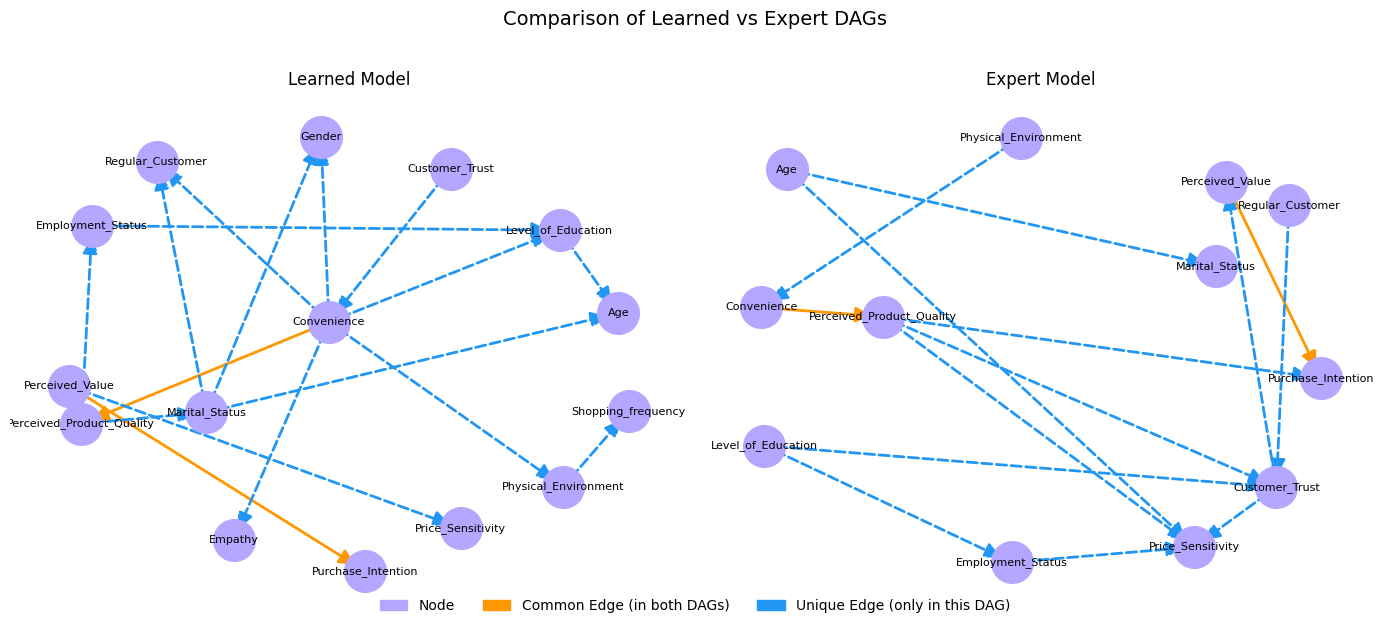

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Extract edges
edges_bn = set(bn_model['model'].edges())
edges_expert = set(G_expert.edges())

# Identify common and unique edges
common_edges = edges_bn & edges_expert
unique_bn = edges_bn - edges_expert
unique_expert = edges_expert - edges_bn

# Create graphs
G_bn = nx.DiGraph()
G_bn.add_nodes_from(bn_model['model'].nodes())
G_bn.add_edges_from(edges_bn)

G_expert = nx.DiGraph()
G_expert.add_nodes_from(G_expert.nodes())
G_expert.add_edges_from(edges_expert)

# Define layouts
pos_bn = nx.spring_layout(G_bn, seed=42, k=2)
pos_expert = nx.spring_layout(G_bn, seed=7, k=2)

#Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#BN Model
nx.draw_networkx_nodes(G_bn, pos_bn, node_color='#B3A7FF', node_size=900, ax=axes[0])
nx.draw_networkx_labels(G_bn, pos_bn, font_color='black', font_size=8, ax=axes[0])
nx.draw_networkx_edges(G_bn, pos_bn, edgelist=common_edges, edge_color='#FF9800', arrows=True, arrowstyle='-|>', arrowsize=23, width=2, ax=axes[0])
nx.draw_networkx_edges(G_bn, pos_bn, edgelist=unique_bn, edge_color='#2196F3', arrows=True, arrowstyle='-|>', arrowsize=23, width=2, style='dashed', ax=axes[0])
axes[0].set_title("Learned Model", fontsize=12)
axes[0].axis('off')

#Expert Model
nx.draw_networkx_nodes(G_expert, pos_expert, node_color='#B3A7FF', node_size=900, ax=axes[1])
nx.draw_networkx_labels(G_expert, pos_expert, font_color='black', font_size=8, ax=axes[1])
nx.draw_networkx_edges(G_expert, pos_expert, edgelist=common_edges, edge_color='#FF9800', arrows=True, arrowstyle='-|>', arrowsize=23, width=2, ax=axes[1])
nx.draw_networkx_edges(G_expert, pos_expert, edgelist=unique_expert, edge_color='#2196F3', arrows=True, arrowstyle='-|>', arrowsize=23, width=2, style='dashed', ax=axes[1])
axes[1].set_title("Expert Model", fontsize=12)
axes[1].axis('off')

# Legend
common_patch = mpatches.Patch(color='#FF9800', label='Common Edge (in both DAGs)')
unique_patch = mpatches.Patch(color='#2196F3', label='Unique Edge (only in this DAG)')
node_patch = mpatches.Patch(color='#B3A7FF', label='Node')

fig.legend(handles=[node_patch, common_patch, unique_patch],
           loc='lower center', ncol=3, fontsize=10, frameon=False)

plt.suptitle("Comparison of Learned vs Expert DAGs", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#Modeling continued

In this phase, the cleaned and preprocessed data is used to train the Bayesian Network model.  
The Maximum Likelihood Estimation method is applied to learn the Conditional Probability Distributions for each node in the network.

This helps to specify the probabilistic relationships between variables identified during the structure learning phase.  

After parameter learning, Bayesian inference is performed to test how changes in certain variables (e.g Purchase Intention) affect others such as Perceived Value, Price Sensitivity, and Perceived Product Quality.

These inference  provide insights into how the model behaves under different evidence scenarios


#Build your Bayesian Networks (Parameter Learning)

In [ ]:
# CPDs parameters using Maximum Likelihood Estimatio
bn_model_learned = bn.parameter_learning.fit(bn_model, retail, methodtype='maximumlikelihood')
bn.print_CPD(bn_model_learned)

Streaming output truncated to the last 5000 lines.
(Price_Sensitivity ⟂ Employment_Status, Level_of_Education, Empathy, Age, Physical_Environment | Gender, Perceived_Product_Quality, Purchase_Intention, Shopping_frequency, Marital_Status, Regular_Customer, Convenience, Customer_Trust)
(Price_Sensitivity ⟂ Employment_Status, Level_of_Education, Age, Convenience, Physical_Environment | Gender, Perceived_Product_Quality, Purchase_Intention, Shopping_frequency, Marital_Status, Empathy, Regular_Customer, Customer_Trust)
(Price_Sensitivity ⟂ Employment_Status, Level_of_Education, Regular_Customer, Age, Physical_Environment | Gender, Perceived_Product_Quality, Purchase_Intention, Shopping_frequency, Marital_Status, Empathy, Convenience, Customer_Trust)
(Price_Sensitivity ⟂ Customer_Trust, Employment_Status, Marital_Status, Age, Physical_Environment | Gender, Perceived_Product_Quality, Purchase_Intention, Shopping_frequency, Level_of_Education, Empathy, Regular_Customer, Convenience)
(Price_Se

{'Marital_Status':     Marital_Status  Perceived_Product_Quality         p
 0                1                       1.00  0.000000
 1                1                       1.25  0.000000
 2                1                       1.50  1.000000
 3                1                       1.75  1.000000
 4                1                       2.00  0.285714
 5                1                       2.25  0.583333
 6                1                       2.50  0.705882
 7                1                       2.75  1.000000
 8                1                       3.00  0.685714
 9                1                       3.25  0.440000
 10               1                       3.50  1.000000
 11               1                       3.75  0.562500
 12               1                       4.00  0.425532
 13               1                       4.25  0.714286
 14               1                       4.50  0.222222
 15               1                       4.75  0.869565
 16          

#Get the inferences for the 4 Combinations mentioned in the Assignment

##Combination 1

In [ ]:
# Provide multiple pieces of evidence
q_multiple_evidence = bn.inference.fit(bn_model_learned,
                                       variables=['Perceived_Value'],
                                       evidence={'Purchase_Intention': 5})
print(q_multiple_evidence)



[bnlearn] >Variable Elimination.
+----+-------------------+-----------+
|    |   Perceived_Value |         p |
+====+===================+===========+
|  0 |              1    | 0         |
+----+-------------------+-----------+
|  1 |              1.67 | 0         |
+----+-------------------+-----------+
|  2 |              2    | 0         |
+----+-------------------+-----------+
|  3 |              2.33 | 0         |
+----+-------------------+-----------+
|  4 |              2.67 | 0         |
+----+-------------------+-----------+
|  5 |              3    | 0         |
+----+-------------------+-----------+
|  6 |              3.33 | 0.0357143 |
+----+-------------------+-----------+
|  7 |              3.67 | 0.0357143 |
+----+-------------------+-----------+
|  8 |              4    | 0.125     |
+----+-------------------+-----------+
|  9 |              4.33 | 0.321429  |
+----+-------------------+-----------+
| 10 |              4.67 | 0.25      |
+----+-------------------+-----


**The probability of a customer’s Perceived Value given that Purchase Intention is at a level of 5**

1. At the lowest rating (1.0 – 2.67), no customers perceive low value, meaning those with the highest intention to buy, they almost never see the product as low value.  
2. Meanwhile around the middle rating (3.0 – 3.67), only a few customers fall in this range (about 3.6%), which suggests that even moderately valued products are rarely chosen by highly intending buyers.  
3. While at the highest ratings (4.0 – 5.0), most customers perceive high value (12.5% to 32.1% for 4.0–4.33, 25% for 4.67, 23.2% for 5.0), meaning customers with top purchase intention mostly see the product as very valuable.



##Combination 2

In [ ]:
# Provide multiple pieces of evidence
q_multiple_evidence = bn.inference.fit(bn_model_learned,
                                       variables=['Price_Sensitivity'],
                                       evidence={'Purchase_Intention': 4})
print(q_multiple_evidence)


[bnlearn] >Variable Elimination.
+----+---------------------+------------+
|    |   Price_Sensitivity |          p |
+====+=====================+============+
|  0 |                1    | 0.0926666  |
+----+---------------------+------------+
|  1 |                1.33 | 0.0126797  |
+----+---------------------+------------+
|  2 |                1.67 | 0.0131125  |
+----+---------------------+------------+
|  3 |                2    | 0.0647201  |
+----+---------------------+------------+
|  4 |                2.33 | 0.129914   |
+----+---------------------+------------+
|  5 |                2.67 | 0.0582173  |
+----+---------------------+------------+
|  6 |                3    | 0.151191   |
+----+---------------------+------------+
|  7 |                3.33 | 0.161635   |
+----+---------------------+------------+
|  8 |                3.67 | 0.0829417  |
+----+---------------------+------------+
|  9 |                4    | 0.160225   |
+----+---------------------+------------+
|


**The probability of a customer’s Price Sensitivity given that Purchase Intention is at a level of 4**

1. At the lowest rating, some customers show low price sensitivity, meaning they are not too worried about price even with a moderate intention to buy.  
2. Meanwile around the middle rating (around 3 to 3.5), most customers fall in this range, which suggests that average interested buyers are somewhat sensitive to price but still open to buying.  
3. While at the highest levels price sensitivity drops a little again, meaning customers with higher purchase intention care less about price and more about the product’s overall value.



##Combination 3

In [ ]:

q_multiple_evidence = bn.inference.fit(bn_model_learned,
                                       variables=['Perceived_Value', 'Perceived_Product_Quality'],
                                       evidence={'Purchase_Intention': 5})
print(q_multiple_evidence)



[bnlearn] >Variable Elimination.
+-----+-------------------+-----------------------------+------------+
|     |   Perceived_Value |   Perceived_Product_Quality |          p |
+=====+===================+=============================+============+
|   0 |              1    |                        1    | 0          |
+-----+-------------------+-----------------------------+------------+
|   1 |              1    |                        1.25 | 0          |
+-----+-------------------+-----------------------------+------------+
|   2 |              1    |                        1.5  | 0          |
+-----+-------------------+-----------------------------+------------+
|   3 |              1    |                        1.75 | 0          |
+-----+-------------------+-----------------------------+------------+
|   4 |              1    |                        2    | 0          |
+-----+-------------------+-----------------------------+------------+
|   5 |              1    |                 


**The probability of a customer’s Perceived Product Quality and Perceived Value given that Purchase Intention is at a level of 5**

1. When rankings are low almost no customers give low scores for value or product quality. This means that people who really intend to buy rarely think the product is poor in quality or value.  
2. At medium ratings (around 3 to 3.5), a few customers show moderate views on value and quality, but this group is small.  
3. While at high ratings (around 4.5 to 5), the largest number of customers rate both value and quality highly. This shows that strong purchase intention is closely linked to positive feelings about the product’s quality and value.


##Combination 4

In [ ]:

q_multiple_evidence = bn.inference.fit(bn_model_learned,
                                       variables=['Perceived_Value', 'Price_Sensitivity'],
                                       evidence={'Purchase_Intention': 4})
print(q_multiple_evidence)



[bnlearn] >Variable Elimination.
+-----+-------------------+---------------------+-------------+
|     |   Perceived_Value |   Price_Sensitivity |           p |
+=====+===================+=====================+=============+
|   0 |              1    |                1    | 0           |
+-----+-------------------+---------------------+-------------+
|   1 |              1    |                1.33 | 0           |
+-----+-------------------+---------------------+-------------+
|   2 |              1    |                1.67 | 0           |
+-----+-------------------+---------------------+-------------+
|   3 |              1    |                2    | 0           |
+-----+-------------------+---------------------+-------------+
|   4 |              1    |                2.33 | 0           |
+-----+-------------------+---------------------+-------------+
|   5 |              1    |                2.67 | 0           |
+-----+-------------------+---------------------+-------------+
|   6 |


**The probability of a customer’s Perceived Value and Price Sensitivity given that Purchase Intention is at a level of 4**

1. At the lowest levels, few customers rate perceived value very low, while price sensitivity varies slightly. This suggests that even with a moderate purchase intention, customers do not strongly undervalue the product.  
2. Around medium ratings (3 to 3.5), many customers show balanced views, they see fair value and have average sensitivity to price. This shows that people with moderate purchase intention are weighing price and value equally.  
3. At higher levels (around 4 to 4.33), most customers rate perceived value highly but still remain somewhat price-conscious. This means even when they see good value, price remains a factor influencing their buying decision.


#6. Model Deployment

### Deployment

In this project, the Bayesian Network model built can be used by a businesses to predict a customer’s purchase intention based on variables like Perceived Value, Price Sensitivity, and Convenience.

In a real world setting, the model could generate dashboards to visualize predicted purchase intentions, create reports showing   which factors influence consumer buying decisions, it can even do automated  recommendations for customers. However, in this assignment, I am not deploying the system in real life, instead I am only mimicing the predictions and analyzing the results using the dataset that was provided. The model could be updated in the future with new data to maintain accuracy if it were deployed.


##Reference:

Provost, F. & Fawcett, T., 2013. Data Science for Business: What You Need to Know about Data Mining and Data-Analytic Thinking. Sebastopol, CA: O’Reilly Media